In [31]:
pip install pmdarima

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
# ...existing code...

# === 0. Imports and config ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use("default")


In [33]:
# === 1. Load pivot data (headline + sectors) from EDA output ===
DATA_PATH = r"C:\git\SwYtch-Team-Monkey\Processed_Data\Indeed_Hiring_Lab\csv"
pivot_csv = os.path.join(DATA_PATH, "indeed_headline_and_sectors_pivot_table.csv")

pivot_df = pd.read_csv(pivot_csv, parse_dates=["dateString"])
pivot_df = pivot_df.set_index("dateString").sort_index()

print("Pivot shape:", pivot_df.shape)
print("Columns:", pivot_df.columns.tolist())

Pivot shape: (2058, 46)
Columns: ['Accounting', 'Administrative Assistance', 'Architecture', 'Arts & Entertainment', 'Banking & Finance', 'Childcare', 'Civil Engineering', 'Cleaning & Sanitation', 'Community & Social Service', 'Construction', 'Customer Service', 'Data & Analytics', 'Dental', 'Driving', 'Education & Instruction', 'Electrical Engineering', 'Food Preparation & Service', 'Headline', 'Hospitality & Tourism', 'Human Resources', 'IT Infrastructure, Operations & Support', 'IT Systems & Solutions', 'Industrial Engineering', 'Installation & Maintenance', 'Legal', 'Loading & Stocking', 'Logistic Support', 'Management', 'Marketing', 'Media & Communications', 'Medical Information', 'Medical Technician', 'Nursing', 'Personal Care & Home Health', 'Pharmacy', 'Physicians & Surgeons', 'Production & Manufacturing', 'Project Management', 'Retail', 'Sales', 'Scientific Research & Development', 'Security & Public Safety', 'Software Development', 'Sports', 'Therapy', 'Veterinary']


In [34]:
# === 2. Train/test split (time-based) ===

# Fill gaps to avoid ARIMA/metric issues
pivot_df = pivot_df.ffill().bfill()

# choose a horizon, e.g. last 3 months as test
test_horizon_months = 3
max_date = pivot_df.index.max()
train_end_date = max_date - pd.DateOffset(months=test_horizon_months)

train_df = pivot_df.loc[:train_end_date]
test_df = pivot_df.loc[train_end_date + pd.offsets.MonthBegin(1):]

print("Train range:", train_df.index.min(), "->", train_df.index.max())
print("Test range :", test_df.index.min(), "->", test_df.index.max())
print("Train shape:", train_df.shape, "Test shape:", test_df.shape)

Train range: 2020-02-01 00:00:00 -> 2025-06-19 00:00:00
Test range : 2025-07-01 00:00:00 -> 2025-09-19 00:00:00
Train shape: (1966, 46) Test shape: (81, 46)



=== Fitting Auto ARIMA for: Headline (backtest) ===
[Headline] MAE: 1.125, RMSE: 1.357


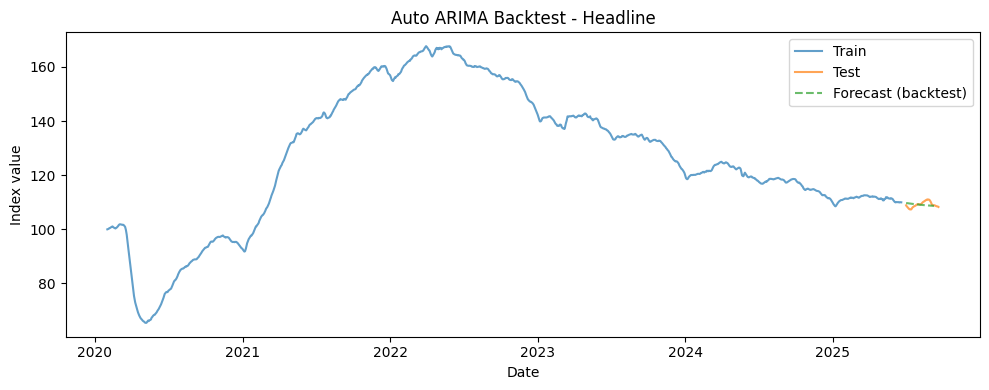


=== Fitting Auto ARIMA for: Headline (full data, future forecast) ===


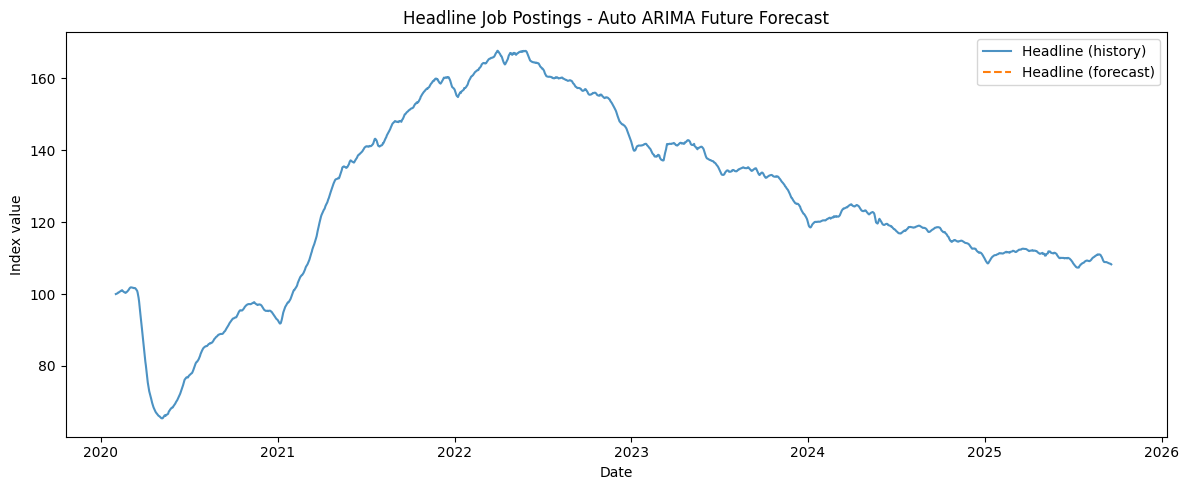

In [ ]:
# === 3. Helper: fit and evaluate one Auto ARIMA series ===

.def fit_evaluate_auto_arima(series_name, train_series, test_series):
.    """
.    Fit auto-ARIMA on one univariate series and evaluate on the test period.
.    Returns: dict with metrics and fitted model.
.    """
.    train_series = train_series.dropna()
.    test_series = test_series.dropna()
.
.    if len(train_series) < 12:
.        print(f"[{series_name}] Not enough training data after dropping NA, skipping.")
.        return None
,
.    print(f"\n=== Fitting Auto ARIMA for: {series_name} (backtest) ===")
.    model = auto_arima(
.        train_series,
.        seasonal=False,        # try seasonal=True, m=12 later if needed
.        trace=False,
.        error_action="ignore",
.        suppress_warnings=True,
.        stepwise=True,
.    )
.
    # Forecast over the length of the test set
    n_periods = len(test_series)
    if n_periods == 0:
        print(f"[{series_name}] No test data, skipping evaluation.")
        return {"model": model, "mae": None, "rmse": None}

    forecast = model.predict(n_periods=n_periods)
    forecast_index = test_series.index
    forecast_series = pd.Series(forecast, index=forecast_index)

    # Align and drop NaNs
    common_index = test_series.index.intersection(forecast_series.index)
    y_true = test_series.loc[common_index]
    y_pred = forecast_series.loc[common_index]

    valid_mask = (~y_true.isna()) & (~y_pred.isna())
    y_true = y_true[valid_mask]
    y_pred = y_pred[valid_mask]

    if len(y_true) == 0:
        print(f"[{series_name}] No valid overlap, skipping metrics.")
        return {"model": model, "mae": None, "rmse": None}

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    print(f"[{series_name}] MAE: {mae:.3f}, RMSE: {rmse:.3f}")

    # Quick diagnostic plot
    plt.figure(figsize=(10, 4))
    plt.plot(train_series.index, train_series, label="Train", alpha=0.7)
    plt.plot(test_series.index, test_series, label="Test", alpha=0.7)
    plt.plot(y_pred.index, y_pred, label="Forecast (backtest)", alpha=0.7, linestyle="--")
    plt.title(f"Auto ARIMA Backtest - {series_name}")
    plt.xlabel("Date")
    plt.ylabel("Index value")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        "model": model,
        "mae": mae,
        "rmse": rmse,
    }

# === 4. Utility: forecast future headline from full dataset ===

def forecast_headline_next_months(pivot_df, months_ahead=6):
    """Train Auto ARIMA on all available Headline data and forecast the next `months_ahead` months.
    Returns a tuple of (headline_series, forecast_series).
    """
    headline_col = "Headline"
    if headline_col not in pivot_df.columns:
        raise KeyError(f"'{headline_col}' column not found in pivot_df")

    full_headline_series = pivot_df[headline_col].dropna()

    if len(full_headline_series) < 12:
        raise ValueError("Not enough Headline data points to train an ARIMA model (need at least 12).")

    print(f"\n=== Fitting Auto ARIMA for: Headline (full data, future forecast, {months_ahead} months) ===")
    model = auto_arima(
        full_headline_series,
        seasonal=False,       # set True + m=12 if you want yearly seasonality
        trace=False,
        error_action="ignore",
        suppress_warnings=True,
        stepwise=True,
    )

    future_periods = months_ahead
    future_forecast = model.predict(n_periods=future_periods)

    # Build a future date index at same frequency as your data (monthly)
    last_date = full_headline_series.index.max()
    future_index = pd.date_range(
        start=last_date + pd.offsets.MonthBegin(1),
        periods=future_periods,
        freq="MS",  # month start
    )

    forecast_series = pd.Series(future_forecast, index=future_index)

    # Plot history + future
    plt.figure(figsize=(12, 5))
    plt.plot(full_headline_series.index, full_headline_series, label="Headline (history)", alpha=0.8)
    plt.plot(forecast_series.index, forecast_series, label="Headline (forecast)", linestyle="--")
    plt.title(f"Headline Job Postings - Auto ARIMA {months_ahead}-Month Future Forecast")
    plt.xlabel("Date")
    plt.ylabel("Index value")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return full_headline_series, forecast_series

In [ ]:
# === 5. Future forecasts for all sectors (optional) ===

future_periods = 12  # same horizon as Headline
last_date = pivot_df.index.max()
future_index = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    periods=future_periods,
    freq="MS",
)

sector_future_forecasts = {}

for col in pivot_df.columns:
    print(f"\n=== Future forecast for sector: {col} ===")
    series = pivot_df[col].dropna()

    if len(series) < 12:
        print(f"[{col}] Not enough data, skipping.")
        continue

    model = auto_arima(
        series,
        seasonal=False,
        trace=False,
        error_action="ignore",
        suppress_warnings=True,
        stepwise=True,
    )

    future_vals = model.predict(n_periods=future_periods)
    sector_future_forecasts[col] = future_vals

# Convert to DataFrame: rows = future dates, columns = sectors
future_df = pd.DataFrame(sector_future_forecasts, index=future_index)
print("\nFuture forecast DataFrame shape:", future_df.shape)

# (Optional) save forecasts
out_dir = r"C:\git\SwYtch-Team-Monkey\Processed_Data\Indeed_Hiring_Lab\forecasts"
os.makedirs(out_dir, exist_ok=True)
future_csv = os.path.join(out_dir, "auto_arima_future_forecasts.csv")
future_df.to_csv(future_csv)
print(f"Saved future forecasts to: {future_csv}")


=== Future forecast for sector: Accounting ===

=== Future forecast for sector: Administrative Assistance ===

=== Future forecast for sector: Architecture ===

=== Future forecast for sector: Arts & Entertainment ===

=== Future forecast for sector: Banking & Finance ===

=== Future forecast for sector: Childcare ===

=== Future forecast for sector: Civil Engineering ===

=== Future forecast for sector: Cleaning & Sanitation ===

=== Future forecast for sector: Community & Social Service ===

=== Future forecast for sector: Construction ===

=== Future forecast for sector: Customer Service ===

=== Future forecast for sector: Data & Analytics ===

=== Future forecast for sector: Dental ===

=== Future forecast for sector: Driving ===

=== Future forecast for sector: Education & Instruction ===

=== Future forecast for sector: Electrical Engineering ===

=== Future forecast for sector: Food Preparation & Service ===

=== Future forecast for sector: Headline ===

=== Future forecast fo

In [ ]:
# === 6. Convenience call: forecast next 6 months of headline job postings ===

# Assumes pivot_df has already been loaded and preprocessed in earlier cells.
headline_history, headline_forecast_6m = forecast_headline_next_months(pivot_df, months_ahead=6)

print("\nNext 6 months of headline job postings forecast:")
print(headline_forecast_6m)